# Figure 3: Decision variable prediction

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env_aws.py
%run run.py connect

Connecting admin@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


In [4]:
from vr4mice.schema.base_analysis import DataFrame
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.schema.interpolated_trajectories import InterpolatedTrials
from vr4mice.schema.session_metrics import TrialMetrics
from vr4mice.analysis import utils
from vr4mice.analysis import regression

from statsmodels.stats.anova import AnovaRM
from scipy.stats import ttest_ind
import scipy.stats as stats

style()

save_fig_path = "notebooks/Paper_figures/Figure_output/"

In [5]:
trial_df = (TrialMetrics() * vr4mice.Groups() * vr4mice.Labels() * (vr4mice.Dataset() & 'session_label = "ar_discrim_occluders"')).fetch(as_dict=True)
trial_df =  pd.concat([pd.DataFrame(x) for x in trial_df])
# Exclude sessions that were not in the list
trial_df, reward_table = utils.apply_inclusion_criteria(trial_df,
                                                        return_excluded=False)
# Create list of included datasets
mouse_list = trial_df.dataset.unique()
trial_df["mouse_name"] = trial_df.dataset.str.split("_").str [0]

In [6]:
trial_df.dataset.nunique(), trial_df.mouse_name.nunique()

(43, 10)

In [7]:
# This takes a while to fetch because we need to fetch data for all trials
dataset_list = []
for d in mouse_list:
    print(d)
    try:
        if len(InterpolatedTrials() & f'dataset = "{d}"') > 0:
            dataset_list.append(pd.DataFrame((InterpolatedTrials() & f'dataset = "{d}"').fetch(as_dict=True)[0]))
        else:
            print("dataset missing")
    except Exception as err:
        print(err, " dataset missing")
interpolated_df = pd.concat(dataset_list)
interpolated_df["mouse_name"] = interpolated_df.dataset.str.split("_").str [0]

31726_2025-03-18_1
31726_2025-03-19_1
31726_2025-03-20_1
31726_2025-03-21_1
31728_2025-03-07_1
31728_2025-03-20_1
31728_2025-03-21_1
J729_2024-11-30_1
J729_2024-12-01_1
J729_2024-12-02_1
J729_2024-12-03_1
J729_2024-12-04_1
J729_2024-12-10_1
J731_2024-12-05_1
Jacana_2024-08-13_1
Jacana_2024-08-14_1
Jacana_2024-08-15_1
Jacana_2024-08-16_1
Jacana_2024-08-19_1
Kiwi_2024-08-10_2
Kiwi_2024-08-11_4
Kiwi_2024-08-12_2
Kiwi_2024-08-13_1
Kiwi_2024-08-14_1
Lemming_2024-08-10_1
Lemming_2024-08-11_1
Lemming_2024-08-12_1
Lemming_2024-08-13_1
Nightingale_2024-08-10_1
Nightingale_2024-08-11_1
Nightingale_2024-08-12_1
Nightingale_2024-08-13_1
Nightingale_2024-08-14_1
Oribi_2024-08-16_1
Oribi_2024-08-19_1
Oribi_2024-08-20_1
Oribi_2024-08-21_1
Oribi_2024-08-22_1
Pheasant_2024-08-15_2
Pheasant_2024-08-16_1
Pheasant_2024-08-19_1
Pheasant_2024-08-20_1
Pheasant_2024-08-21_1


In [8]:
box_df = base_analysis.BoxDataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"})

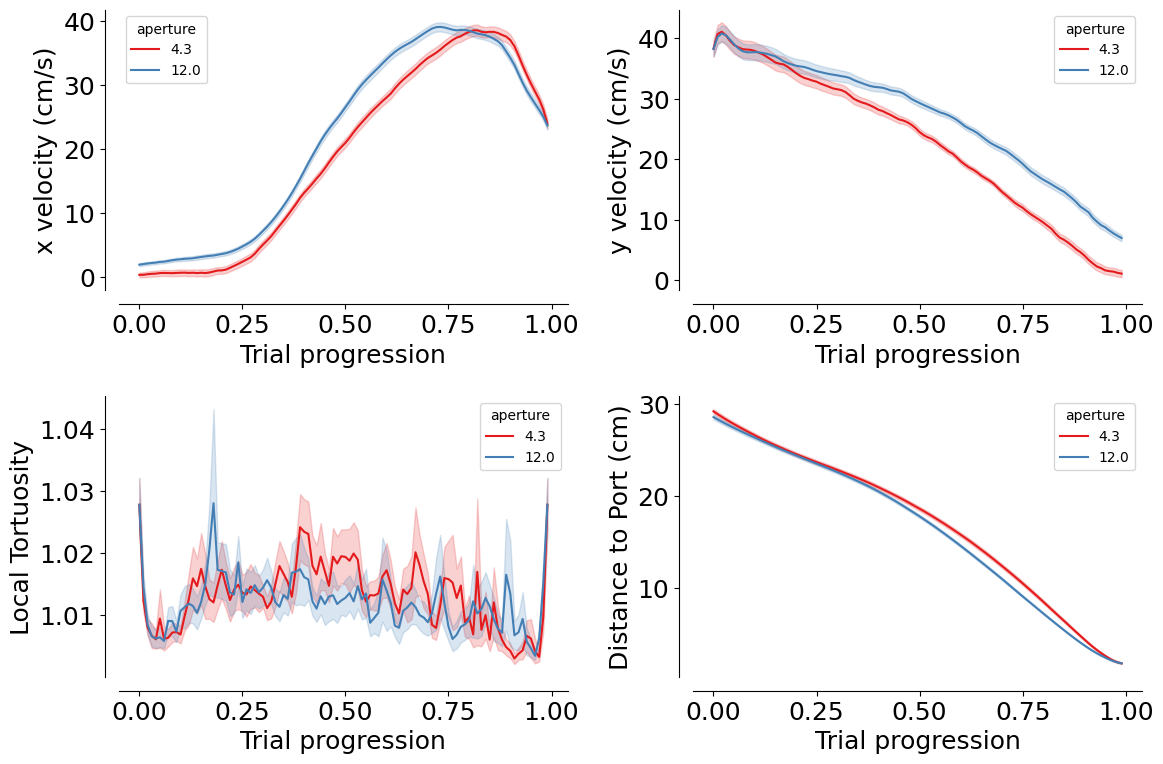

In [9]:
mean_mouse = interpolated_df.groupby(
    ["dataset", "aperture", "trial_length"], as_index=False
).mean(numeric_only=True)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.flatten()

for (i, label), label_str in zip(enumerate(
    ["velocity_x_fliped", "velocity_y", "local_tortuosity", "distance_to_choice"]
), ["x velocity (cm/s)", "y velocity (cm/s)", "Local Tortuosity", "Distance to Port (cm)"]):
    sns.lineplot(
        data=mean_mouse,
        x="trial_length",
        y=label,
        palette=(
            plotting.colors_aperture[:2]
            if len(mean_mouse.aperture.unique()) == 2
            else "viridis"
        ),
        hue="aperture",
        errorbar="se",
        ax=ax[i],
    )
    ax[i].set_ylabel(label_str)
    ax[i].set_xlabel("Trial progression")
    sns.despine(ax=ax[i], offset=10)
    
plt.tight_layout(pad=2)
plt.savefig(save_fig_path + "figure3_velocity_tortuosity_distance.svg", bbox_inches="tight", transparent=True)

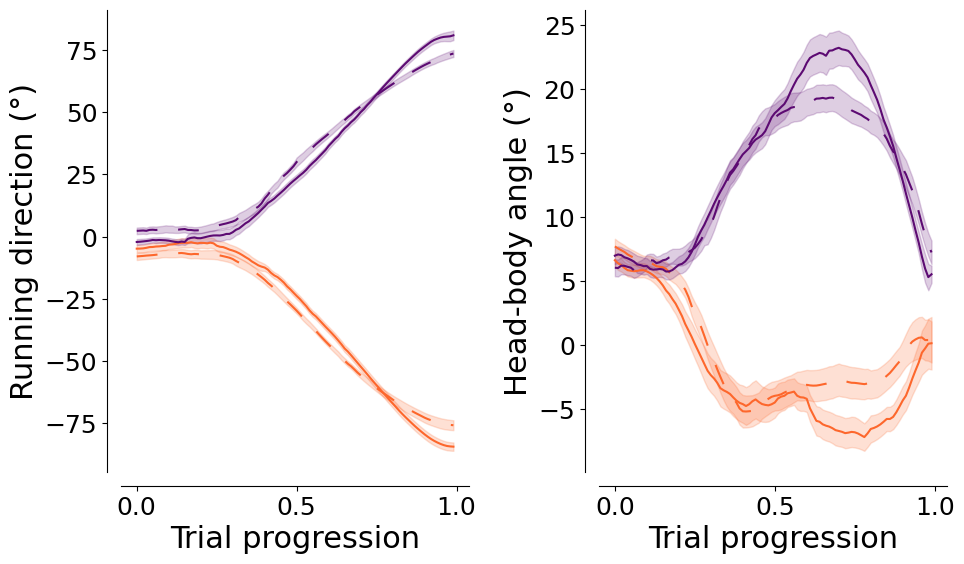

In [10]:
mean_mouse = interpolated_df.groupby(
    ["dataset", "aperture", "trial_left_choice", "trial_length"], as_index=False
).mean(numeric_only=True)

fig, ax = plt.subplots(1, 2, figsize=(10, 6))
ax = ax.flatten()

dash_styles = {
    mean_mouse.aperture.unique()[0]: "",         # Solid
    mean_mouse.aperture.unique()[1]: (10, 10)      # Dashed
}

for (i, label), label_str in zip(enumerate(["heading_dir", "head_angle"]), 
                                 ["Running direction (°)", "Head-body angle (°)"]):
    sns.lineplot(
        data=mean_mouse,
        x="trial_length",
        y=label,
        palette=plotting.colors_choice[::-1]
        if len(mean_mouse.aperture.unique()) == 2
        else "viridis",
        hue="trial_left_choice"
        if len(mean_mouse.aperture.unique()) == 2
        else "aperture",
        style=(
            "aperture"
            if len(mean_mouse.aperture.unique()) == 2
            else "trial_left_choice"
        ),
        errorbar="se",
        dashes=dash_styles,
        ax=ax[i],
    )
    ax[i].set_ylabel(label_str, fontsize=22)
    ax[i].set_xlabel("Trial progression", fontsize=22)
    sns.despine(ax=ax[i], offset=10)

    ax[i].legend().remove()
plt.tight_layout(pad=2)
plt.savefig(save_fig_path + "figure3_heading_dir_head_angle.svg", bbox_inches="tight", transparent=True)
plt.savefig(save_fig_path + "figure3_heading_dir_head_angle.png", bbox_inches="tight", transparent=True, dpi=300)

In [11]:
interpolated_df["mouse_name"] = interpolated_df.dataset.str.split("_").str[0]
interpolated_df["heading_dir_flipped"] = interpolated_df.heading_dir * interpolated_df.flip_one_side
interpolated_df["head_angle_flipped"] = interpolated_df.head_angle * interpolated_df.flip_one_side

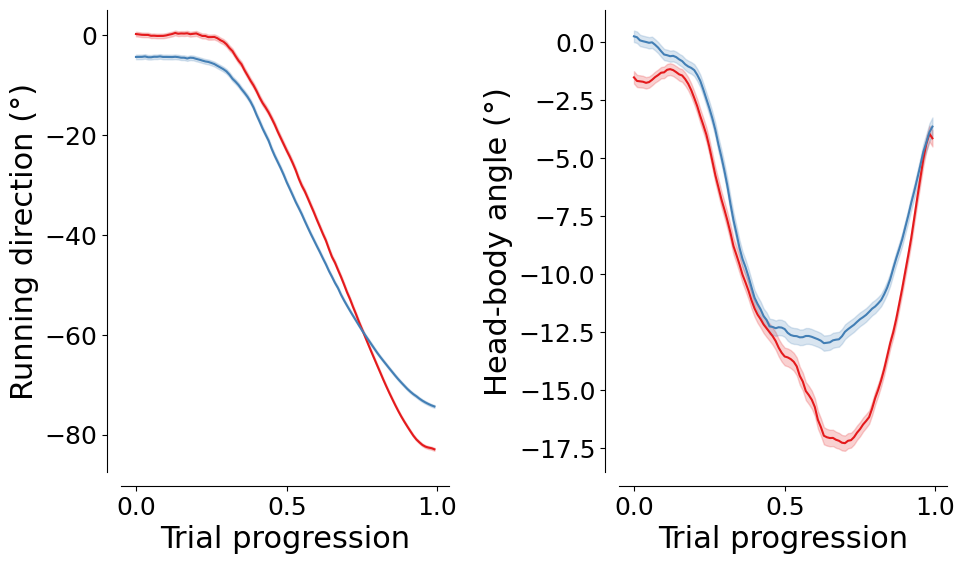

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(10, 6))
ax = ax.flatten()

sns.lineplot(
    data=interpolated_df,
    x="trial_length",
    y="heading_dir_flipped",
    hue="aperture",
    errorbar="se",
    palette=plotting.colors_aperture,
    ax=ax[0],
)
ax[0].set_ylabel("Running direction (°)", fontsize=22)
ax[0].set_xlabel("Trial progression", fontsize=22)
sns.despine(ax=ax[0], offset=10)
ax[0].legend([], [], frameon=False)

sns.lineplot(
    data=interpolated_df,
    x="trial_length",
    y="head_angle_flipped",
    hue="aperture",
    errorbar="se",
    palette=plotting.colors_aperture,
    ax=ax[1],
)
ax[1].set_ylabel("Head-body angle (°)", fontsize=22)
ax[1].set_xlabel("Trial progression", fontsize=22)
sns.despine(ax=ax[1], offset=10)
ax[1].legend([], [], frameon=False)

plt.tight_layout(pad=2)

In [13]:
# print(
#     AnovaRM(
#         data=interpolated_df.groupby(
#             ["dataset", "aperture", "trial_length"], as_index=False
#         ).mean(),
#         depvar="heading_dir_flipped",
#         subject="dataset",
#         within=["aperture", "trial_length"],
#     ).fit()
# )

# print(
#     AnovaRM(
#         data=interpolated_df.groupby(
#             ["dataset", "aperture", "trial_length"], as_index=False
#         ).mean(),
#         depvar="head_angle_flipped",
#         subject="dataset",
#         within=["aperture", "trial_length"],
#     ).fit()
# )

In [14]:
# agg = (
#     interpolated_df
#     .groupby(["dataset", "aperture", "trial_length"], as_index=False)[
#         ["heading_dir_flipped", "head_angle_flipped"]
#     ]
#     .mean()
# )

# aperture_order = sorted(agg.aperture.unique())

# p_values = []
# for tl in sorted(agg.trial_length.unique()):
#     section = agg[agg.trial_length == tl]
#     t = ttest_ind(
#         section[section.aperture == aperture_order[0]].heading_dir_flipped,
#         section[section.aperture == aperture_order[1]].heading_dir_flipped,
#     )
#     p_values.append({"segment": tl, "p_value": t.pvalue})

# p_value_df = pd.DataFrame(p_values)
# p_value_df["p_value_corr"] = stats.false_discovery_control(p_value_df.p_value)

# fig, ax = plt.subplots(1, 1, figsize=(6, 5))
# plt.plot(p_value_df.segment, p_value_df.p_value_corr, c="k")

# plt.hlines(0.05, xmin=0, xmax=1, color="red", linestyle="dashed")

# plt.xlabel("Trial progression")
# plt.ylabel("Corrected p-value")

# sns.despine(offset=10)
# plt.savefig(save_fig_path + "figure3_heading_dir_p_values.svg", bbox_inches="tight", transparent=True)

In [15]:
# aperture_order = sorted(agg.aperture.unique())
# p_values = []
# for tl in sorted(agg.trial_length.unique()):
#     section = agg[agg.trial_length == tl]
#     t = ttest_ind(
#         section[section.aperture == aperture_order[0]].head_angle_flipped,
#         section[section.aperture == aperture_order[1]].head_angle_flipped,
#     )
#     p_values.append({"segment": tl, "p_value": t.pvalue})

# p_value_df = pd.DataFrame(p_values)
# p_value_df["p_value_corr"] = stats.false_discovery_control(p_value_df.p_value)

# fig, ax = plt.subplots(1, 1, figsize=(6, 5))
# plt.plot(p_value_df.segment, p_value_df.p_value_corr, c="k")

# plt.hlines(0.05, xmin=0, xmax=1, color="red", linestyle="dashed")

# plt.xlabel("Trial progression")
# plt.ylabel("Corrected p-value")

# sns.despine(offset=10)
# plt.savefig(save_fig_path + "figure3_head_angle_p_values.svg", bbox_inches="tight", transparent=True)

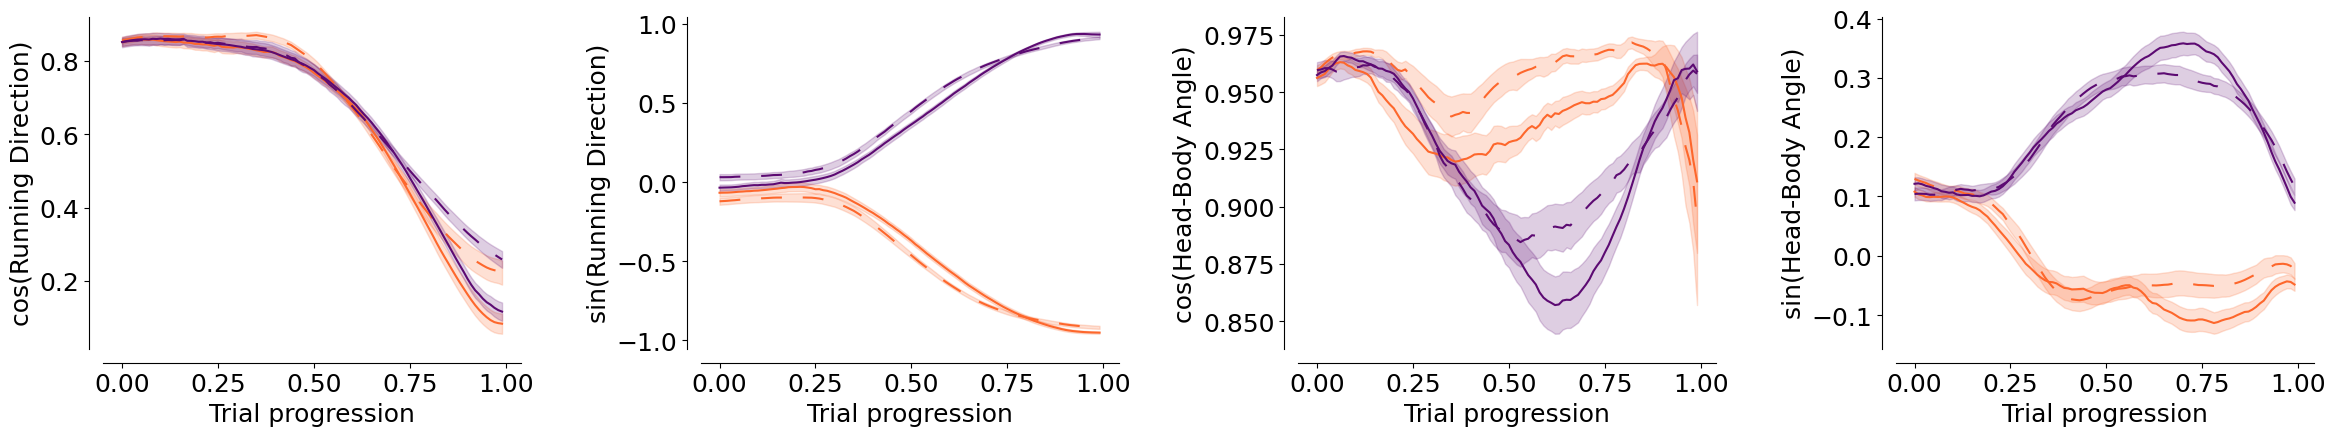

In [16]:
mean_mouse = interpolated_df.groupby(
    ["dataset", "aperture", "trial_left_choice", "trial_length"], as_index=False
).mean(numeric_only=True)

fig, ax = plt.subplots(1, 4, figsize=(24, 5))
ax = ax.flatten()

dash_styles = {
    mean_mouse.aperture.unique()[0]: "",         # Solid
    mean_mouse.aperture.unique()[1]: (10, 10)      # Dashed
}

for (i, label), label_str in zip(enumerate(
    ["heading_dir_cos", "heading_dir_sin", "head_angle_cos", "head_angle_sin"]
), ["cos(Running Direction)", "sin(Running Direction)", "cos(Head-Body Angle)", "sin(Head-Body Angle)"]):
    sns.lineplot(
        data=mean_mouse,
        x="trial_length",
        y=label,
        palette=plotting.colors_choice[::-1]
        if len(mean_mouse.aperture.unique()) == 2
        else "viridis",
        hue="trial_left_choice"
        if len(mean_mouse.aperture.unique()) == 2
        else "aperture",
        style=(
            "aperture"
            if len(mean_mouse.aperture.unique()) == 2
            else "trial_left_choice"
        ),
        errorbar="se",
        ax=ax[i],
        dashes=dash_styles,
    )
    ax[i].set_ylabel(label_str)
    ax[i].set_xlabel("Trial progression")
    sns.despine(ax=ax[i], offset=10)

    ax[i].legend().remove()
    
plt.tight_layout(pad=3)
plt.savefig(save_fig_path + "figure3_heading_dir_head_angle_cos_sin.svg", bbox_inches="tight", transparent=True)
plt.savefig(save_fig_path + "figure3_heading_dir_head_angle_cos_sin.png", bbox_inches="tight", transparent=True, dpi=300)

In [17]:
model_labels = regression.model_labels 

In [18]:
interpolated_df["aperture"] = interpolated_df["aperture"].astype(float)

df_model, coef = regression.predict_decision(
    df=interpolated_df, label=model_labels, per_mouse=True
)

In [19]:
coef.shape

(43, 12)

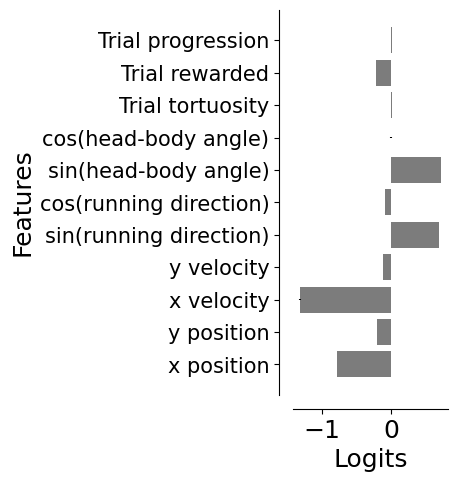

In [20]:
# Logits of the regression
import scipy.stats
fig, ax = plt.subplots(1, 1, figsize=(2, 5))
ax.barh(
    regression.model_labels,
    np.mean(coef[:, 1:], axis=0),
    yerr=scipy.stats.sem(coef[:, 1:], axis=0),
    color="#7C7C7C",
)
sns.despine(offset=10, ax=ax)

ax.set_yticks(np.arange(len(regression.model_labels)))
ax.set_yticklabels(regression.clean_model_labels, rotation=0, ha="right", fontsize=15)
ax.set_xlabel("Logits")
ax.set_ylabel("Features")

plt.savefig(save_fig_path + "figure3_dual_occluder_model_logits.svg", transparent=False)

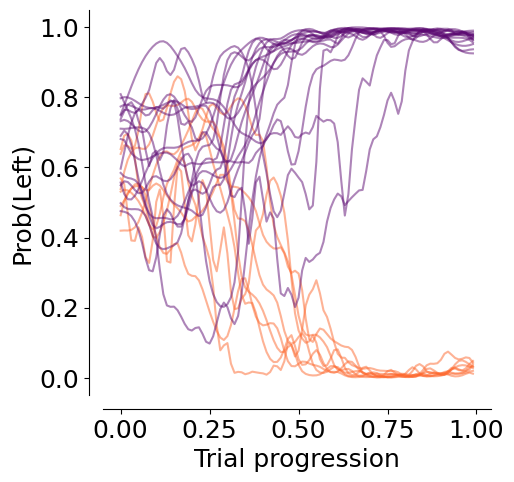

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

group = df_model[(df_model.dataset == "Kiwi_2024-08-14_1")]

trials = [
    94,
    15,
    66,
    170,
    224,
    195,
    56,
    203,
    88,
    239,
    113,
    91,
    186,
    248,
    109,
    164,
    188,
    60,
    229,
    182,
    156,
    197,
    52,
    45,
]  # 110, 156, 190,  22, 210,  24,  51,  78,
# 239,  97,  24, 176, 168, 184, 123, 156]

group = group[group.trial.isin(np.array(trials))]
sns.lineplot(
    data=group,
    x="trial_length",
    y="proba_left",
    hue="trial_left_choice",
    errorbar=None,
    estimator=None,
    units="trial",
    palette=plotting.colors_choice[::-1],
    sort=False,
    alpha=0.5,
    ax=ax,
)
ax.set_ylabel("Prob(Left)")
ax.set_xlabel("Trial progression")
ax.legend([], [], frameon=False)
sns.despine(offset=10)

plt.savefig(
    save_fig_path + "figure3_dual_occluder_dynamic_decision_variable.svg",
    transparent=True,
)

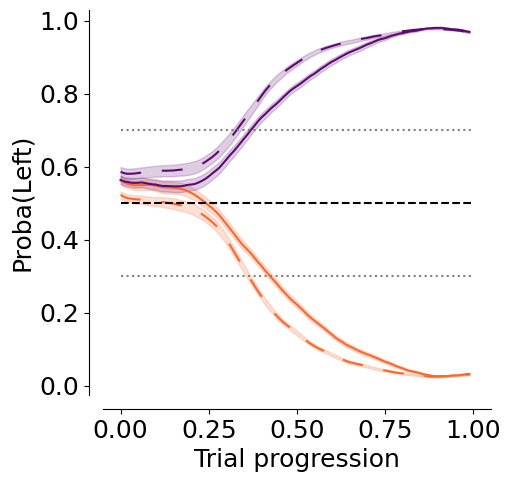

In [22]:
df_model_mean =  df_model.groupby(["dataset", "aperture", "trial_left_choice", "trial_length"], as_index=False).mean()
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

dash_styles = {
    mean_mouse.aperture.unique()[0]: "",         # Solid
    mean_mouse.aperture.unique()[1]: (10, 10)      # Dashed
}

sns.lineplot(
    data=df_model_mean,
    x="trial_length",
    y="proba_left",
    hue="trial_left_choice",
    style="aperture",
    palette=plotting.colors_choice[::-1],
    sort=False,
    alpha=1,
    ax=ax,
    errorbar="se",
    dashes=dash_styles
)
ax.set_ylabel("Proba(Left)")
ax.set_xlabel("Trial progression")

ax.hlines(0.5, xmin=0, xmax=1, colors="black", linestyles="dashed")
ax.hlines(0.7, xmin=0, xmax=1, colors="gray", linestyles="dotted")
ax.hlines(0.3, xmin=0, xmax=1, colors="gray", linestyles="dotted")
ax.legend([], [], frameon=False)
sns.despine(offset=10)

plt.savefig(
    save_fig_path + "figure3_dual_occluder_dynamic_decision_variable_avg.png",
    transparent=True,
    dpi=300,
)

plt.savefig(
    save_fig_path + "figure3_dual_occluder_dynamic_decision_variable_avg.svg",
    transparent=True,
)

In [23]:
df_model_mean =  df_model.groupby(["dataset", "aperture", "trial_length"], as_index=False).mean()

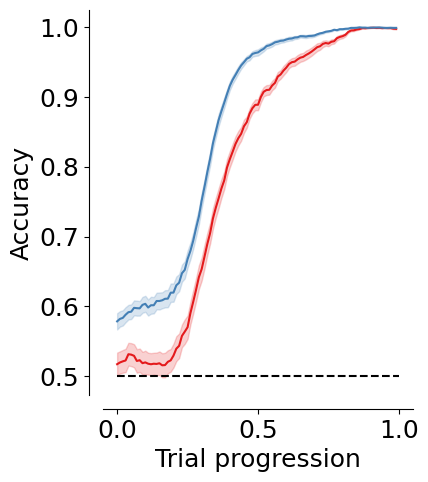

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(4, 5))
sns.lineplot(
    data=df_model_mean,
    x="trial_length",
    y="accuracy",
    hue="aperture",
    palette=plotting.colors_aperture,
    sort=False,
    alpha=1,
    ax=ax,
    errorbar="se"
)
ax.hlines(0.5, 0, 1, color="black", linestyle="--")

ax.set_ylabel("Accuracy")
ax.set_xlabel("Trial progression")
ax.legend([], [], frameon=False)
sns.despine(offset=10)

plt.savefig(
    save_fig_path + "figure3_dual_occluder_model_accuracy.svg", transparent=True
)

In [25]:
df_model["trial_length_bin"] = pd.cut(
    df_model["trial_length"], bins=50
)  # Adjust bins as needed
df_anova = df_model.groupby(
    ["dataset", "aperture", "trial_length_bin"], as_index=False
)["accuracy"].mean()

print(
    AnovaRM(
        data=df_anova,
        depvar="accuracy",
        subject="dataset",
        within=["aperture", "trial_length_bin"],
    ).fit()
)

                           Anova
                           F Value   Num DF   Den DF  Pr > F
------------------------------------------------------------
aperture                    51.5508  1.0000   42.0000 0.0000
trial_length_bin          1029.1316 49.0000 2058.0000 0.0000
aperture:trial_length_bin   15.0817 49.0000 2058.0000 0.0000



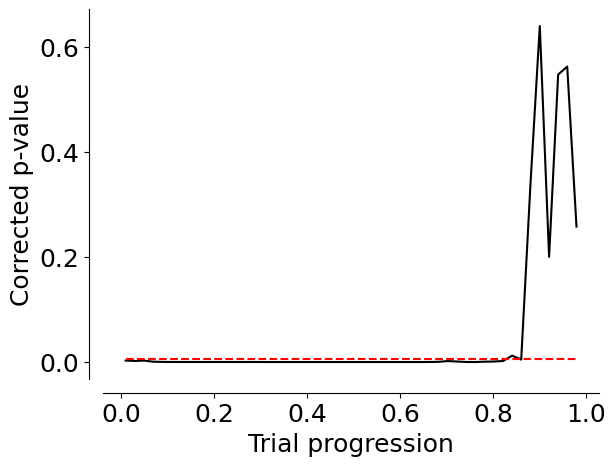

In [26]:
p_values = []
for i in df_anova.trial_length_bin.unique():
    section = df_anova[df_anova.trial_length_bin == i]
    t = ttest_ind(
        section[section.aperture == section.aperture.unique()[0]].accuracy,
        section[section.aperture == section.aperture.unique()[1]].accuracy,
    )
    p_values.append(pd.DataFrame({"segment": i, "p_value": t.pvalue}, index=[0]))

p_value_df = pd.concat(p_values)
p_value_df["p_value_corr"] = stats.false_discovery_control(p_value_df.p_value)

# Convert interval bins to numeric midpoints
p_value_df["segment"] = p_value_df["segment"].apply(lambda x: x.mid)

plt.plot(p_value_df.segment, p_value_df.p_value_corr, c="k")

plt.hlines(
    0.005,
    xmin=p_value_df.segment.min(),
    xmax=p_value_df.segment.max(),
    color="red",
    linestyle="dashed",
)

plt.xlabel("Trial progression")
plt.ylabel("Corrected p-value")

sns.despine(offset=10)
plt.savefig(
    save_fig_path + "figure3_dual_occluder_model_accuracy_pvalue.svg", transparent=True
)

## Get the decision points

In [101]:
decision_points = regression.find_decision_point(df_model, 
                                                 threshold_uncertainty=0.4)

Decision Time: 0.31


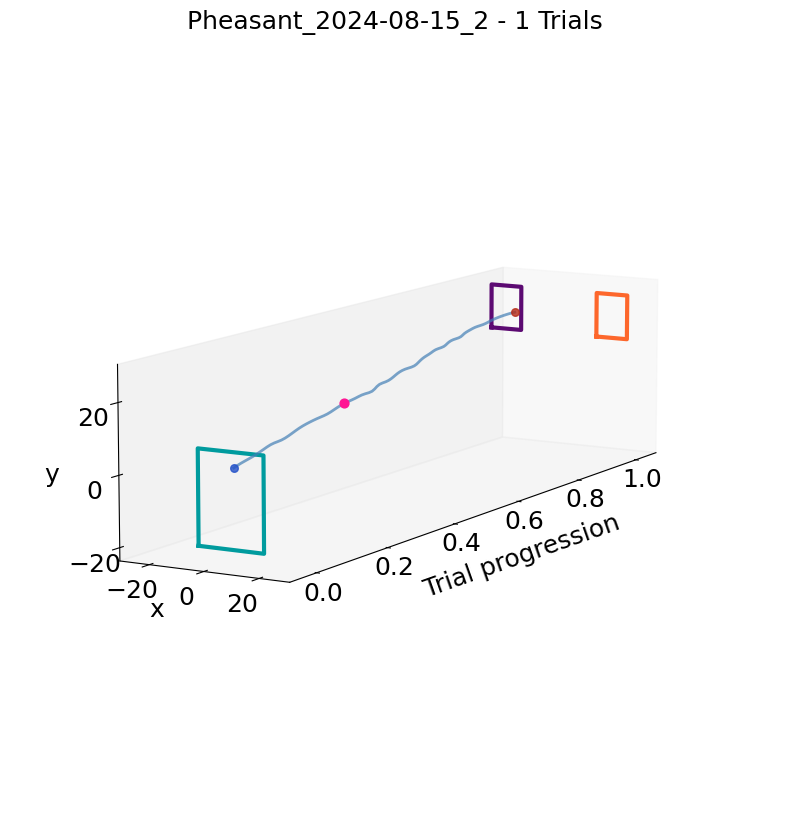

In [102]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

ax = plotting.plot_session_3d(
    df=interpolated_df[interpolated_df.dataset == "Pheasant_2024-08-15_2"],
    box_df=box_df,
    trial_ids=[69],
    ax=ax,
    color_by_aperture=True,
    color_by_choice=False,
    decision_points=decision_points[decision_points.dataset == "Pheasant_2024-08-15_2"]
)

plt.savefig(save_fig_path + "figure3_dual_occluder_3d_trajectory_wide.svg", bbox_inches="tight", transparent=True)

Decision Time: 0.39


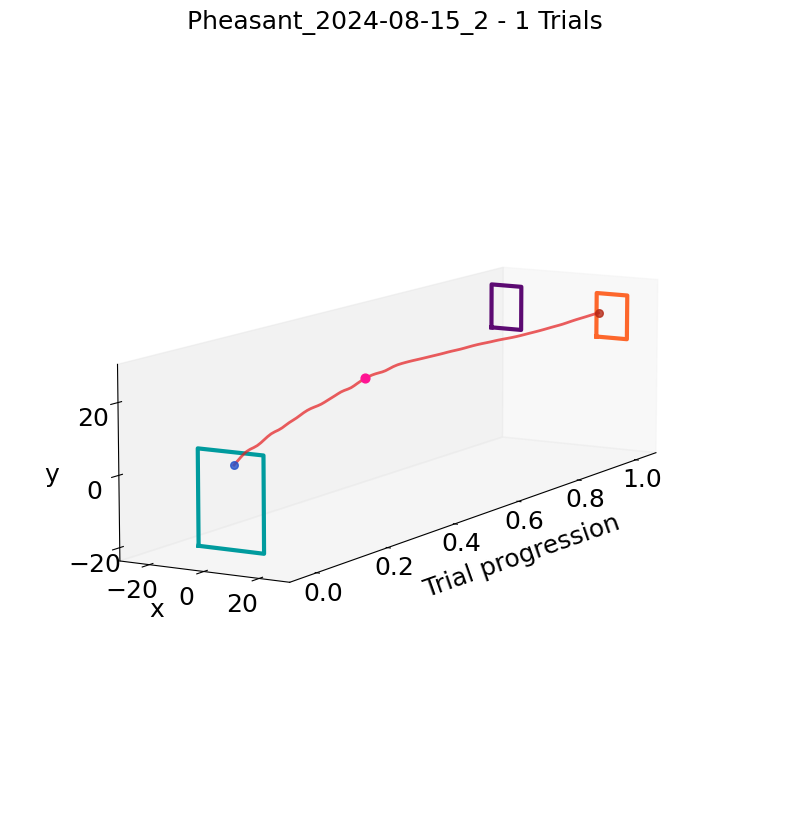

In [103]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

ax = plotting.plot_session_3d(
    df=interpolated_df[interpolated_df.dataset == "Pheasant_2024-08-15_2"],
    box_df=box_df,
    trial_ids=[125],
    ax=ax,
    color_by_aperture=True,
    color_by_choice=False,
    decision_points=decision_points[decision_points.dataset == "Pheasant_2024-08-15_2"]
)

plt.savefig(save_fig_path + "figure3_dual_occluder_3d_trajectory_narrow.svg", bbox_inches="tight", transparent=True)

In [104]:
with open("notebooks/Paper_figures/info_matrix_52x52x31_124.npy", "rb") as file:
    info_matrix_narrow = np.rot90(np.load(file), k=1)
with open("notebooks/Paper_figures/info_matrix_52x52x31_346.npy", "rb") as file:
    info_matrix_wide = np.rot90(np.load(file), k=1)

info_matrices = [info_matrix_narrow, info_matrix_wide]

# normalize info matrices to max 1
info_matrices = [im / im.max() for im in info_matrices]

/tmp/ipykernel_1182156/1849721202.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  base_cmap = cm.get_cmap("PuOr")


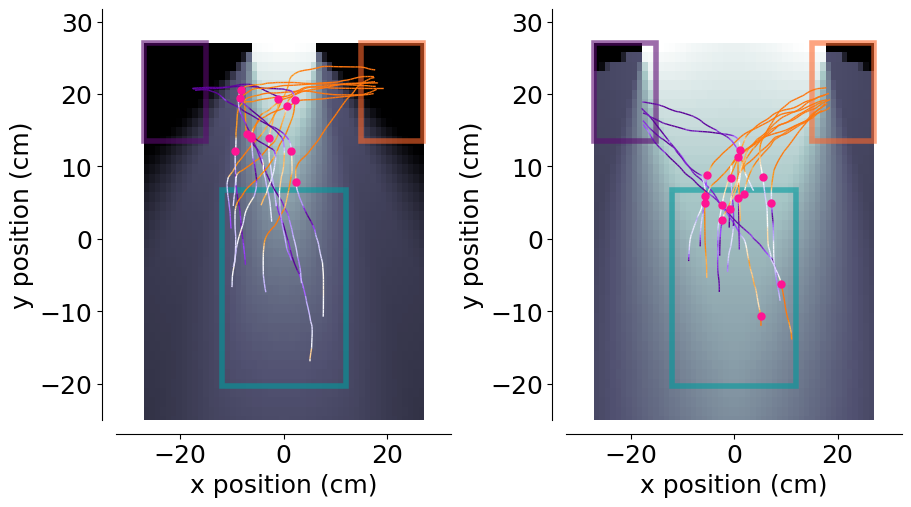

In [105]:
import matplotlib.colors as mcolors
import matplotlib.cm as cm

fig, ax = plt.subplots(
    1, len(df_model.aperture.unique()), figsize=(9, 5), constrained_layout=True
)

decision_color = "deeppink"
session_to_plot = "Pheasant_2024-08-15_2"
box_df = base_analysis.BoxDataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"})

trials = [44, 45, 19, 62, 61, 45, 85, 41, 43, 41, 50, 75, 24, 69, 84, 74, 10] + [
    63,
    30,
    78,
    47,
    33,
    5,
    17,
    9,
    47,
    30,
    99,
    11,
    12,
    15,
]

# Start from PuOr
base_cmap = cm.get_cmap("PuOr")

# Make a brighter version by rescaling luminance
def brighten(cmap, factor=2):
    colors = cmap(np.linspace(0, 1, 256))
    rgb = mcolors.rgb_to_hsv(colors[:, :3])
    rgb[:, 2] = rgb[:, 2] * factor  # brighten value channel
    rgb[:, 2] = np.clip(rgb[:, 2], 0, 1)
    colors[:, :3] = mcolors.hsv_to_rgb(rgb)
    return mcolors.ListedColormap(colors)

bright_puor = brighten(base_cmap)

for i, aperture in enumerate(df_model.aperture.unique()[::-1]):
    regression.plot_decision_points_on_trajectory(
        df_model[
            (df_model.dataset == session_to_plot) & (df_model.aperture == aperture)
        ],
        box_df,
        decision_point=decision_points[
            (decision_points.dataset == session_to_plot)
            & (decision_points.aperture == aperture)
        ],
        color=decision_color,
        trials=trials,
        ax=ax[i],
        cmap=bright_puor,
    )
    
    xlim = ax[i].get_xlim()
    ylim = ax[i].get_ylim()

    im = ax[i].imshow(info_matrices[i], 
                 cmap="bone", 
                 extent=[-27, 27, -27, 27],
                 zorder=-10)
    
    ax[i].set_xlim(xlim)
    ax[i].set_ylim(ylim)
    ax[i].set_aspect(1.4)
    ax[i].set_xlabel("x position (cm)")
    ax[i].set_ylabel("y position (cm)")
    sns.despine(offset=10, ax=ax[i])

#fig.colorbar(im, ax=ax, orientation="vertical", fraction=0.03, pad=0.04, label="Information content rate")
plt.savefig(
    save_fig_path + "figure3_dual_occluder_decision_points_trajectories_bright.svg",
    transparent=True,
)

## Behavior around the decision point

In [ ]:
decision_window = 3
decision_metrics = []
for idx, row in decision_points[decision_points.dataset==session_to_plot].iterrows():
    dataset = row["dataset"]
    aperture = row["aperture"]
    trial = row["trial"]
    decision_length = row["trial_length"]
    
    trial_data = interpolated_df[
        (interpolated_df.dataset == dataset) &
        (interpolated_df.aperture == aperture) &
        (interpolated_df.trial == trial)
    ]
    
    # Find the index of the decision point
    decision_index_candidates = trial_data[
        np.isclose(trial_data.trial_length, decision_length)
    ].index
    if len(decision_index_candidates) == 0:
        continue
    decision_index = decision_index_candidates[0]
    
    # Get the windows around the decision point
    before_window_data = trial_data.loc[
        decision_index - decision_window : decision_index - 1
    ]
    after_window_data = trial_data.loc[
        decision_index + 1 : decision_index + decision_window
    ]
    
    # Compute average metrics in each window
    before_metrics = before_window_data.mean(numeric_only=True)
    before_metrics["dataset"] = dataset
    before_metrics["aperture"] = aperture
    before_metrics["trial"] = trial
    before_metrics["decision_trial_length"] = decision_length
    before_metrics["period"] = "before"
    
    after_metrics = after_window_data.mean(numeric_only=True)
    after_metrics["dataset"] = dataset
    after_metrics["aperture"] = aperture
    after_metrics["trial"] = trial
    after_metrics["decision_trial_length"] = decision_length
    after_metrics["period"] = "after"
    
    decision_metrics.append(before_metrics)
    decision_metrics.append(after_metrics)

decision_metrics_df = pd.DataFrame(decision_metrics)

In [107]:
# Compare metrics before vs after
metric_cols = [
    "velocity_x_fliped",
    "velocity_y",
    "heading_dir_flipped",
    "head_angle_flipped",
]

summary = (
    decision_metrics_df.groupby("period")[metric_cols]
    .agg(["mean", "sem"])
    .transpose()
    .reset_index()
    .rename(columns={"level_0": "metric", "level_1": "stat"})
    .pivot(index="metric", columns="stat")
)

# Paired comparison per trial (before vs after)
paired = (
    decision_metrics_df
    .pivot_table(index=["dataset", "aperture", "trial"], columns="period", values=metric_cols)
    .dropna()
)

ttest_results = []
for metric in metric_cols:
    before = paired[(metric, "before")]
    after = paired[(metric, "after")]
    stat = stats.ttest_rel(before, after, nan_policy="omit")
    ttest_results.append({
        "metric": metric,
        "t_stat": stat.statistic,
        "p_value": stat.pvalue,
        "n": before.shape[0]
    })
ttest_df = pd.DataFrame(ttest_results)

In [108]:
# Random-point control per trial (same window size)
rng = np.random.default_rng(0)
random_metrics = []
n_random_points = 10
for idx, row in decision_points[decision_points.dataset == session_to_plot].iterrows():
    dataset = row["dataset"]
    aperture = row["aperture"]
    trial = row["trial"]
    
    trial_data = interpolated_df[
        (interpolated_df.dataset == dataset)
        & (interpolated_df.aperture == aperture)
        & (interpolated_df.trial == trial)
    ].sort_values("trial_length").reset_index(drop=True)
    
    n_available = len(trial_data) - 2 * decision_window
    if n_available <= 0:
        continue
    
    sample_size = min(n_random_points, n_available)
    rand_indices = rng.choice(
        np.arange(decision_window, len(trial_data) - decision_window),
        size=sample_size,
        replace=False,
    )
    
    for rand_id, rand_idx in enumerate(rand_indices):
        rand_length = trial_data.loc[rand_idx, "trial_length"]
        
        before_window_data = trial_data.iloc[rand_idx - decision_window : rand_idx]
        after_window_data = trial_data.iloc[rand_idx + 1 : rand_idx + decision_window + 1]
        
        before_metrics = before_window_data.mean(numeric_only=True)
        before_metrics["dataset"] = dataset
        before_metrics["aperture"] = aperture
        before_metrics["trial"] = trial
        before_metrics["decision_trial_length"] = rand_length
        before_metrics["period"] = "before"
        before_metrics["random_id"] = rand_id
        
        after_metrics = after_window_data.mean(numeric_only=True)
        after_metrics["dataset"] = dataset
        after_metrics["aperture"] = aperture
        after_metrics["trial"] = trial
        after_metrics["decision_trial_length"] = rand_length
        after_metrics["period"] = "after"
        after_metrics["random_id"] = rand_id
        
        random_metrics.append(before_metrics)
        random_metrics.append(after_metrics)
    
random_metrics_df = pd.DataFrame(random_metrics)
random_metrics_avg = (
    random_metrics_df
    .groupby(["dataset", "aperture", "trial", "period"], as_index=False)[metric_cols]
    .mean()
 )
random_paired = (
    random_metrics_avg
    .pivot_table(index=["dataset", "aperture", "trial"], columns="period", values=metric_cols)
    .dropna()
 )
random_diff_df = random_paired.xs("after", level=-1, axis=1) - random_paired.xs("before", level=-1, axis=1)

true_diff_df = paired.xs("after", level=-1, axis=1) - paired.xs("before", level=-1, axis=1)
common_index = true_diff_df.index.intersection(random_diff_df.index)

compare_results = []
for metric in metric_cols:
    stat = stats.ttest_rel(
        true_diff_df.loc[common_index, metric],
        random_diff_df.loc[common_index, metric],
        nan_policy="omit",
    )
    compare_results.append({
        "metric": metric,
        "t_stat": stat.statistic,
        "p_value": stat.pvalue,
        "n": len(common_index),
    })
compare_df = pd.DataFrame(compare_results)

In [109]:
compare_df

,metric,t_stat,p_value,n
0,velocity_x_fliped,13.727757,5.993019e-32,238
1,velocity_y,-0.227378,8.203255e-01,238
2,heading_dir_flipped,-5.479333,1.088861e-07,238
3,head_angle_flipped,-12.596054,3.426033e-28,238


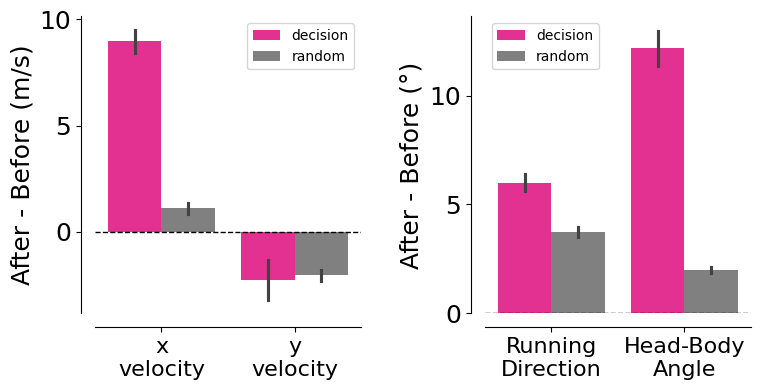

In [110]:
# Plot after - before difference (mean ± SEM) for each metric
plot_frames = []
for label, data in [("decision", true_diff_df), ("random", random_diff_df)]:
    df_long = data.reset_index().melt(
        id_vars=["dataset", "aperture", "trial"],
        var_name="metric",
        value_name="delta",
    )
    df_long["condition"] = label
    plot_frames.append(df_long)
plot_df = pd.concat(plot_frames, ignore_index=True)

velocity_metrics = ["velocity_x_fliped", "velocity_y"]
angle_metrics = ["heading_dir_flipped", "head_angle_flipped"]

plot_df["delta_plot"] = plot_df["delta"]
plot_df.loc[plot_df.metric.isin(angle_metrics), "delta_plot"] = plot_df.loc[
    plot_df.metric.isin(angle_metrics), "delta_plot"
].abs()

label_map = {
    "head_angle_flipped": "Head-Body\nAngle",
    "heading_dir_flipped": "Running\nDirection",
    "velocity_x_fliped": "x\nvelocity",
    "velocity_y": "y\nvelocity",
}

# Single figure with two axes (velocity and angles)
vel_df = plot_df[plot_df.metric.isin(velocity_metrics)]
ang_df = plot_df[plot_df.metric.isin(angle_metrics)]
vel_order = [m for m in metric_cols if m in velocity_metrics]
ang_order = [m for m in metric_cols if m in angle_metrics]
vel_labels = [label_map.get(m, m) for m in vel_order]
ang_labels = [label_map.get(m, m) for m in ang_order]

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=False)

sns.barplot(
    data=vel_df,
    x="metric",
    y="delta_plot",
    hue="condition",
    order=vel_order,
    errorbar="se",
    palette=["deeppink", "grey"],
    ax=axes[0],
 )
axes[0].axhline(0, color="black", linewidth=1, linestyle="--")
axes[0].set_xlabel("")
axes[0].set_ylabel("After - Before (m/s)")
axes[0].set_xticklabels(vel_labels, ha="right")
axes[0].tick_params(axis="x", labelsize=16)
axes[0].legend(title="")
sns.despine(offset=10, ax=axes[0])

sns.barplot(
    data=ang_df,
    x="metric",
    y="delta_plot",
    hue="condition",
    order=ang_order,
    errorbar="se",
    palette=["deeppink", "grey"],
    ax=axes[1],
 )
axes[1].axhline(0, color="black", linewidth=1, linestyle="--")
axes[1].set_ylabel("After - Before (°)")
axes[1].set_xlabel("")
axes[1].set_xticklabels(ang_labels, ha="right")
axes[1].tick_params(axis="x", labelsize=16)
axes[1].legend(title="")
sns.despine(offset=10, ax=axes[1])

plt.tight_layout()


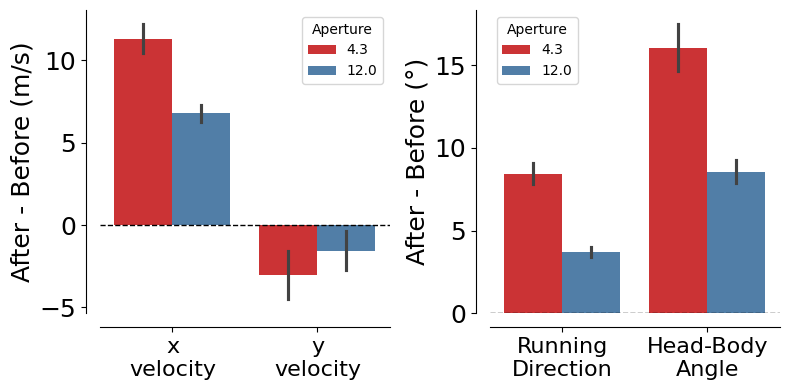

In [111]:
# Plot after - before difference by aperture (decision only)
aperture_plot_df = true_diff_df.reset_index().melt(
    id_vars=["dataset", "aperture", "trial"],
    var_name="metric",
    value_name="delta",
)
aperture_plot_df["delta_plot"] = aperture_plot_df["delta"]
aperture_plot_df.loc[aperture_plot_df.metric.isin(angle_metrics), "delta_plot"] = (
    aperture_plot_df.loc[aperture_plot_df.metric.isin(angle_metrics), "delta_plot"].abs()
 )

vel_df_ap = aperture_plot_df[aperture_plot_df.metric.isin(velocity_metrics)]
ang_df_ap = aperture_plot_df[aperture_plot_df.metric.isin(angle_metrics)]

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=False)

sns.barplot(
    data=vel_df_ap,
    x="metric",
    y="delta_plot",
    hue="aperture",
    order=vel_order,
    errorbar="se",
    palette=plotting.colors_aperture[: len(vel_df_ap.aperture.unique())],
    ax=axes[0],
 )
axes[0].axhline(0, color="black", linewidth=1, linestyle="--")
axes[0].set_xlabel("")
axes[0].set_ylabel("After - Before (m/s)")
axes[0].set_xticklabels(vel_labels, ha="right")
axes[0].tick_params(axis="x", labelsize=16)
axes[0].legend(title="Aperture")
sns.despine(offset=10, ax=axes[0])

sns.barplot(
    data=ang_df_ap,
    x="metric",
    y="delta_plot",
    hue="aperture",
    order=ang_order,
    errorbar="se",
    palette=plotting.colors_aperture[: len(ang_df_ap.aperture.unique())],
    ax=axes[1],
 )
axes[1].axhline(0, color="black", linewidth=1, linestyle="--")
axes[1].set_xlabel("")
axes[1].set_ylabel("After - Before (°)")
axes[1].set_xticklabels(ang_labels, ha="right")
axes[1].tick_params(axis="x", labelsize=16)
axes[1].legend(title="Aperture")
sns.despine(offset=10, ax=axes[1])

plt.tight_layout()


In [112]:
# Significance between aperture conditions (decision only)
apertures = sorted(aperture_plot_df.aperture.unique())
aperture_stats = []
for metric in metric_cols:
    vals_a = aperture_plot_df[(aperture_plot_df.metric == metric) & (aperture_plot_df.aperture == apertures[0])]["delta_plot"]
    vals_b = aperture_plot_df[(aperture_plot_df.metric == metric) & (aperture_plot_df.aperture == apertures[1])]["delta_plot"]
    stat = stats.ttest_ind(vals_a, vals_b, nan_policy="omit")
    aperture_stats.append({
        "metric": metric,
        "aperture_a": apertures[0],
        "aperture_b": apertures[1],
        "t_stat": stat.statistic,
        "p_value": stat.pvalue,
        "n_a": vals_a.shape[0],
        "n_b": vals_b.shape[0],
    })
aperture_ttest_df = pd.DataFrame(aperture_stats)
aperture_ttest_df

,metric,aperture_a,aperture_b,t_stat,p_value,n_a,n_b
0,velocity_x_fliped,4.3,12.0,4.426910,1.461846e-05,115,123
1,velocity_y,4.3,12.0,-0.809088,4.192794e-01,115,123
2,heading_dir_flipped,4.3,12.0,6.827774,7.235980e-11,115,123
3,head_angle_flipped,4.3,12.0,4.883283,1.924023e-06,115,123


## Velocity aligned on the decision point

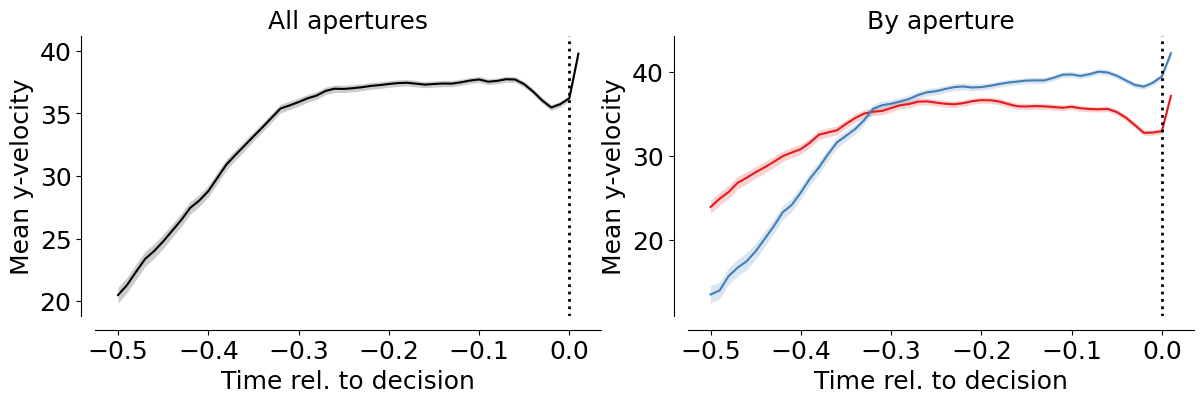

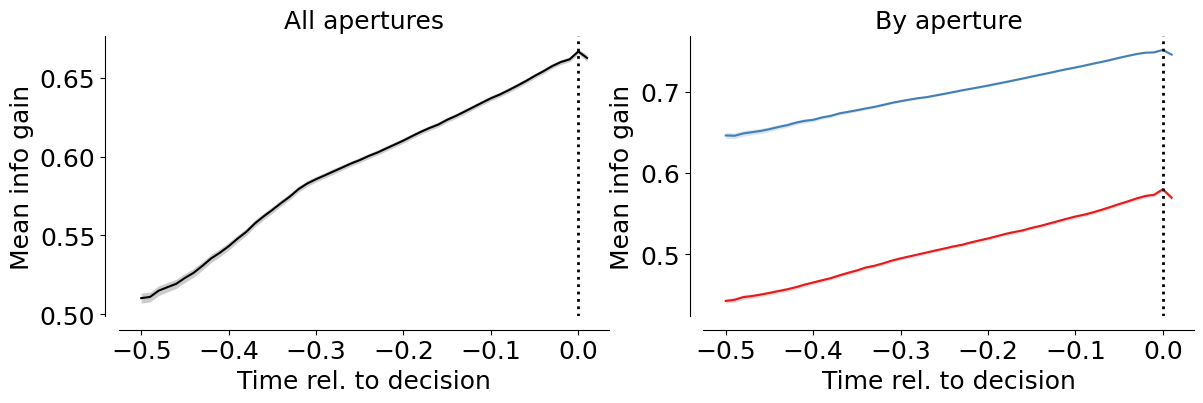

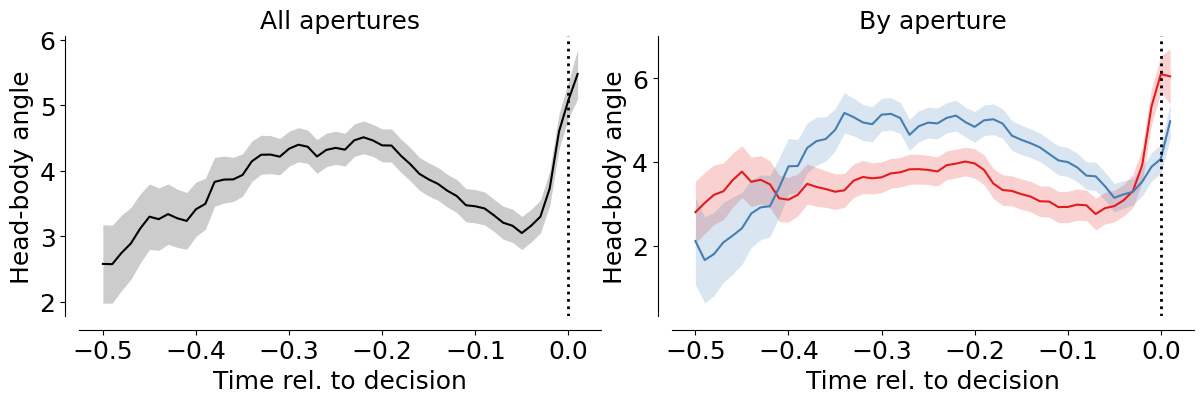

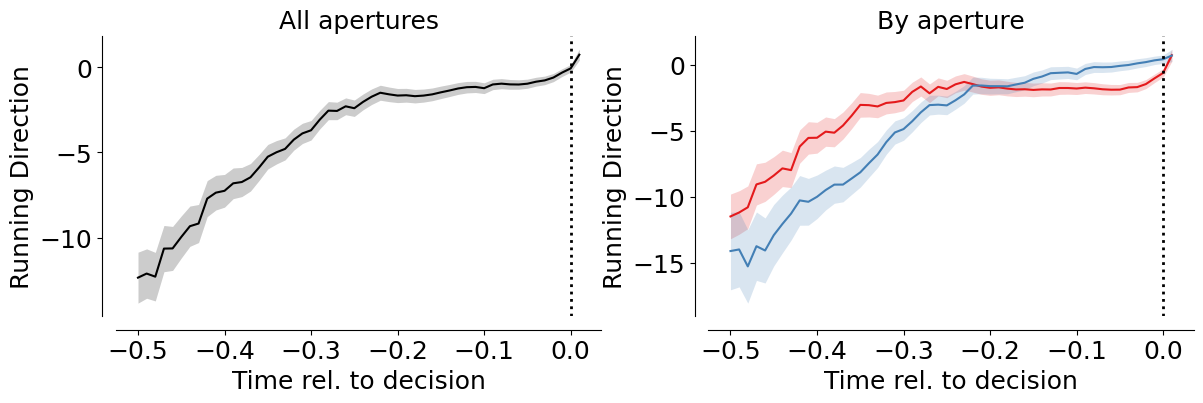

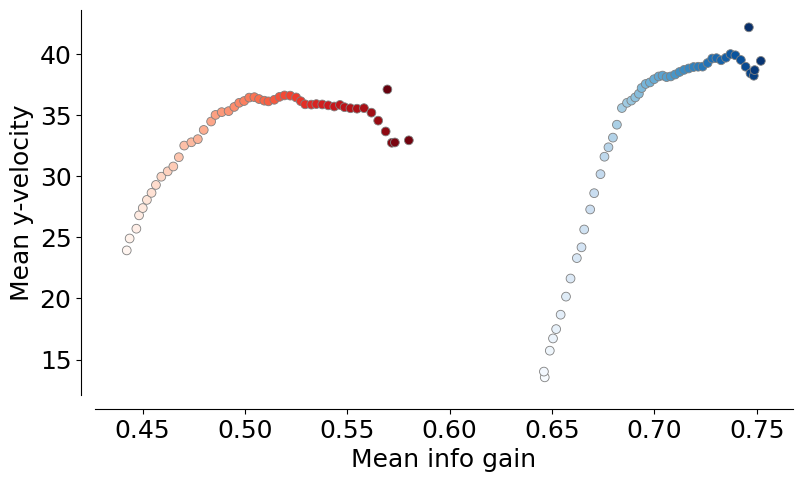

In [128]:
# Average velocity/info_gain around decision point + correlation
bin_size = 0.01
pre_window = 0.5
post_window = 0.02

dp_all = decision_points[["dataset", "aperture", "trial", "trial_length"]].rename(
    columns={"trial_length": "decision_tl"}
 )

df_all = interpolated_df.merge(
    dp_all,
    on=["dataset", "aperture", "trial"],
    how="inner",
 ).copy()

df_all["t_rel"] = df_all["trial_length"] - df_all["decision_tl"]
df_all = df_all[(df_all.t_rel >= -pre_window) & (df_all.t_rel <= post_window)]

bins = np.arange(-pre_window, post_window + bin_size, bin_size)
df_all["t_bin"] = pd.cut(df_all.t_rel, bins=bins, labels=bins[:-1])

def _bin_mean_sem(frame, value_col):
    binned = (
        frame.groupby(["aperture", "t_bin"])[value_col]
        .agg(["mean", "sem"])
        .reset_index()
    )
    binned["t_bin"] = binned["t_bin"].astype(float)
    return binned

metrics = [
    {
        "col": "velocity_y",
        "ylabel": "Mean y-velocity",
        "file": "figure3_velocity_around_decision.svg",
    },
    {
        "col": "info_gain",
        "ylabel": "Mean info gain",
        "file": "figure3_info_gain_around_decision.svg",
    },
    {
        "col": "head_angle",
        "ylabel": "Head-body angle",
        "file": "figure3_head_angle_around_decison.svg"
    },
    {
        "col": "heading_dir",
        "ylabel": "Running Direction",
        "file": "figure3_heading_dir_around_decison.svg"
    }
]

binned_by_metric = {}
for metric in metrics:
    value_col = metric["col"]
    binned = _bin_mean_sem(df_all, value_col)
    binned_by_metric[value_col] = binned
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

    # Overall
    overall = (
        df_all.groupby("t_bin")[value_col]
        .agg(["mean", "sem"])
        .reset_index()
    )
    overall["t_bin"] = overall["t_bin"].astype(float)
    axes[0].plot(overall.t_bin, overall["mean"], color="black", linewidth=1.5)
    axes[0].fill_between(
        overall.t_bin,
        overall["mean"] - overall["sem"],
        overall["mean"] + overall["sem"],
        color="black",
        alpha=0.2,
        linewidth=0,
    )
    axes[0].axvline(0, color="black", linestyle=":", linewidth=2)
    axes[0].set_title("All apertures")
    axes[0].set_ylabel(metric["ylabel"])
    axes[0].set_xlabel("Time rel. to decision")
    sns.despine(ax=axes[0])

    # By aperture
    for idx, ap in enumerate(sorted(df_all.aperture.unique())[:2]):
        ap_df = binned[binned.aperture == ap]
        color = plotting.colors_aperture[idx] if "plotting" in globals() else None
        axes[1].plot(ap_df.t_bin, ap_df["mean"], color=color, linewidth=1.5, label=f"Aperture {ap}")
        axes[1].fill_between(
            ap_df.t_bin,
            ap_df["mean"] - ap_df["sem"],
            ap_df["mean"] + ap_df["sem"],
            color=color,
            alpha=0.2,
            linewidth=0,
        )
    axes[1].axvline(0, color="black", linestyle=":", linewidth=2)
    axes[1].set_title("By aperture")
    axes[1].set_xlabel("Time rel. to decision")
    axes[1].set_ylabel(metric["ylabel"])
    sns.despine(ax=axes[1])

    plt.tight_layout()
    sns.despine(offset=10)
    plt.savefig(save_fig_path + metric["file"])

# Correlation between velocity and info gain (binned means)
vel_binned = binned_by_metric["velocity_y"]
info_binned = binned_by_metric["info_gain"]
corr_df = vel_binned.merge(
    info_binned,
    on=["aperture", "t_bin"],
    suffixes=("_vel", "_info"),
 )

fig, ax = plt.subplots(1, 1, figsize=(9, 5))
apertures_sorted = sorted(corr_df.aperture.unique())[:2]
cmap_by_ap = {
    apertures_sorted[0]: "Reds",
    apertures_sorted[1]: "Blues",
}
for ap in apertures_sorted:
    ap_df = corr_df[corr_df.aperture == ap].dropna(subset=["mean_info", "mean_vel"])
    if ap_df.empty:
        continue
    sc = ax.scatter(
        ap_df["mean_info"],
        ap_df["mean_vel"],
        c=ap_df["t_bin"],
        cmap=cmap_by_ap[ap],
        s=40,
        edgecolors="grey",
        linewidths=0.6,
    )
ax.set_xlabel("Mean info gain")
ax.set_ylabel("Mean y-velocity")
sns.despine(offset=10)

## Information contained at decision point per condition

In [115]:
def get_info_at_position(info_matrix, position):
    # Assuming info_matrix is a 2D numpy array and position is a tuple (x, y)
    x, y = position
    # Convert position to matrix indices
    x_idx = int(x + 27)
    y_idx = int(y + 27)
    
    # but the matrix is 52x42 so the positions need to be scaled down
    x_idx_norm = int(x_idx * (51 / 54))
    y_idx_norm = int(y_idx * (41 / 54))
    
    y_idx_norm = info_matrix.shape[0] - 1 - y_idx_norm
    return info_matrix[y_idx_norm, x_idx_norm]  # Note: y comes first in matrix indexing

In [116]:
# Compute information for each timepoint in interpolated_df
interpolated_df["info_gain"] = interpolated_df.apply(
    lambda row: get_info_at_position(
        info_matrices[0] if row.aperture == 4.3 else info_matrices[1],
        (row.x, row.y),
    ),
    axis=1,
)

In [117]:
decision_points.dropna(subset=["x", "y"], inplace=True)
decision_points["info_gain"] = decision_points.apply(
    lambda row: get_info_at_position(
        info_matrices[0] if row.aperture == 4.3 else info_matrices[1],
        (row.x, row.y),
    ),
    axis=1,
)

In [118]:
interpolated_df = interpolated_df.sort_values(by=["mouse_name", "dataset"])
session_map = interpolated_df.groupby(["mouse_name", "dataset"]).ngroup()
interpolated_df["session_idx"] = interpolated_df.groupby("mouse_name")["dataset"].transform(lambda x: x.map({val: i+1 for i, val in enumerate(x.unique())}))

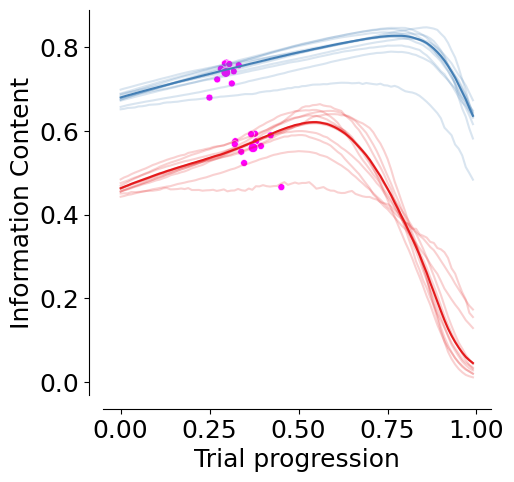

In [119]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

for mouse in interpolated_df.mouse_name.unique():
    sns.lineplot(
        data=interpolated_df[(interpolated_df.mouse_name==mouse)],
        x="trial_length",
        y="info_gain",
        hue="aperture",
        palette=plotting.colors_aperture,
        errorbar=None,
        ax=ax,
        alpha=0.2
    )
    
sns.lineplot(
        data=interpolated_df,
        x="trial_length",
        y="info_gain",
        hue="aperture",
        palette=plotting.colors_aperture,
        errorbar="se",
        ax=ax
    )

# Add decision points
mean_decision_points = decision_points.groupby(["mouse_name", "aperture"], as_index=False).mean(numeric_only=True)
sns.scatterplot(
    data=mean_decision_points,
    x="trial_length",
    y="info_gain",
    hue="aperture",
    palette=["magenta", "magenta"],
    ax=ax,
)

sns.scatterplot(
    data=mean_decision_points.groupby("aperture", as_index=False).mean(numeric_only=True),
    x="trial_length",
    y="info_gain",
    hue="aperture",
    palette=["magenta", "magenta"],
    s=50,
    ax=ax,
)

ax.set_ylabel("Information Content")
ax.set_xlabel("Trial progression")
ax.legend([], [], frameon=False)
sns.despine(offset=10)

#### for specific points (start vs. decision)

In [120]:
# for each trial, get the initial position
initial_positions = interpolated_df.groupby(
    ["mouse_name", "dataset", "aperture", "trial"], as_index=False
).first()[["mouse_name", "dataset", "aperture", "trial", "x", "y"]]

# Get info at initial position
initial_positions["info_gain"] = initial_positions.apply(
    lambda row: get_info_at_position(
        info_matrices[0] if row.aperture == 4.3 else info_matrices[1],
        (row.x, row.y),
    ),
    axis=1,
)

In [121]:
decision_points["mouse_name"] = decision_points.dataset.str.split("_").str [0]

# Decision point information available
info_at_decision_per_session = decision_points.groupby(["mouse_name", "dataset", "aperture"], as_index=False).apply(
    lambda x: get_info_at_position(
        info_matrices[0] if x.aperture.values[0] == 4.3 else info_matrices[1],
        (x.x.mean(), x.y.mean()),
    )
)
info_at_decision_per_session = info_at_decision_per_session.rename(columns={None: "info_gain"})
info_at_decision_per_session["count"] = info_at_decision_per_session["info_gain"]
info_at_decision_per_session = pd.DataFrame(info_at_decision_per_session.reset_index())
info_at_decision_per_session.aperture = info_at_decision_per_session.aperture.round(2).astype(str)

# Initial position information available
initial_positions = initial_positions.groupby(["mouse_name", "dataset", "aperture"], as_index=False)["info_gain"].mean()
initial_positions["count"] = initial_positions["info_gain"]
initial_positions = pd.DataFrame(initial_positions.reset_index())
initial_positions.aperture = initial_positions.aperture.astype(float).round(2).astype(str)

# Difference in information available
information_difference = info_at_decision_per_session.copy()
information_difference["info_gain"] = information_difference["info_gain"] - initial_positions["info_gain"]
information_difference["count"] = information_difference["info_gain"]
information_difference = pd.DataFrame(information_difference.reset_index())
information_difference.aperture = information_difference.aperture.astype(float).round(2).astype(str)

2026-02-06 10:47:24,054::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-06 10:47:24,060::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-06 10:47:24,163::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-06 10:47:24,168::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-06 10:47:24,181::INFO::category.py::Using categorical un

2026-02-06 10:47:24,518::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-06 10:47:24,522::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-06 10:47:24,534::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-06 10:47:24,539::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-06 10:47:24,556::INFO::category.py::Using categorical un

Information at Initiation
mean: 0.46107538928717773 +/- 0.002586592804136966
12.0-4.3: TtestResult(statistic=123.34056502985698, pvalue=2.113213797110614e-55, df=42)
mean: 0.6788369968352709 +/- 0.0022108611985671815
Information at Decision
mean: 0.6582829857179847 +/- 0.008023140625914487
12.0-4.3: TtestResult(statistic=12.681719925470038, pvalue=5.945795435913401e-16, df=42)
mean: 0.7480159815799396 +/- 0.0026152144572059487
Information Difference
mean: 0.19720759643080688 +/- 0.007915331996148198
12.0-4.3: TtestResult(statistic=-16.6403094545475, pvalue=4.2501511526089826e-20, df=42)
mean: 0.06917898474466876 +/- 0.0018585064830619422


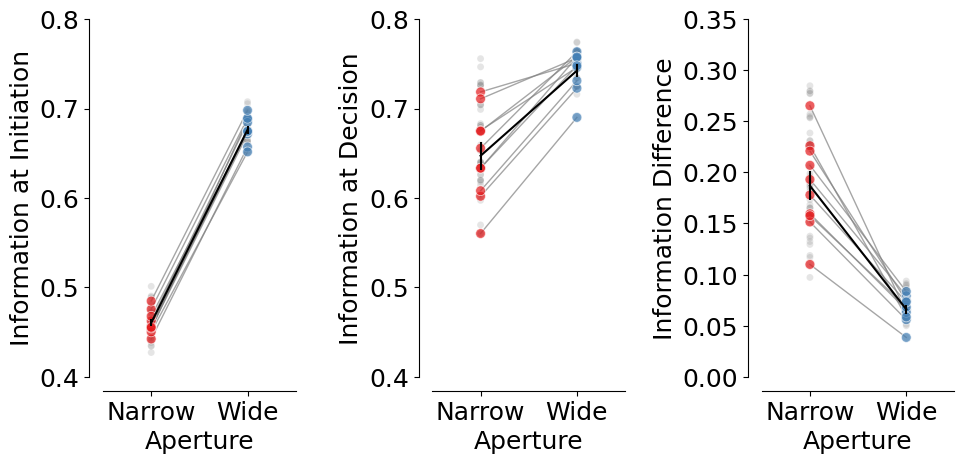

In [122]:
fig, ax = plt.subplots(1, 3, figsize=(10, 5))


plotting._plot_bar_counts(
    counts=initial_positions,
    label_x="aperture",
    alpha=0.2,
    ax=ax[0],
    per_mouse=True,
    cmap=plotting.colors_aperture[0:2],
)
ax[0].invert_xaxis()
ax[0].set_ylabel("Information at Initiation")
ax[0].set_xlim(-0.5, 1.5)
ax[0].set_xticks([0, 1], ["Narrow", "Wide"])
ax[0].set_xlabel("Aperture")
ax[0].legend([], [], frameon=False)
sns.despine(offset=10, ax=ax[0])

plotting._plot_bar_counts(
    counts=info_at_decision_per_session,
    label_x="aperture",
    alpha=0.2,
    ax=ax[1],
    per_mouse=True,
    cmap=plotting.colors_aperture[0:2],
)
ax[1].invert_xaxis()
ax[1].set_ylabel("Information at Decision")
ax[1].set_xlim(-0.5, 1.5)
ax[1].set_xticks([0, 1], ["Narrow", "Wide"])
ax[1].set_xlabel("Aperture")
ax[1].legend([], [], frameon=False)
sns.despine(offset=10, ax=ax[1])

plotting._plot_bar_counts(
    counts=information_difference,
    label_x="aperture",
    alpha=0.2,
    ax=ax[2],
    per_mouse=True,
    cmap=plotting.colors_aperture[0:2],
)
ax[2].invert_xaxis()
ax[2].set_ylabel("Information Difference")
ax[2].set_xlim(-0.5, 1.5)
ax[2].set_xticks([0, 1], ["Narrow", "Wide"])
ax[2].set_xlabel("Aperture")
ax[2].legend([], [], frameon=False)
sns.despine(offset=10, ax=ax[2])

ax[0].set_ylim(0.4, 0.8)
ax[1].set_ylim(0.4, 0.8)
ax[2].set_ylim(0, 0.35)

plt.tight_layout(pad=2)
plt.savefig(
    save_fig_path + "figure3_dual_occluder_information_quantification.svg",
    transparent=True,
)


for info, label in zip([initial_positions, info_at_decision_per_session, information_difference],
                       ["Information at Initiation", "Information at Decision", "Information Difference"]):
    print(label)
    for i in info.aperture.unique():
        for j in info.aperture.unique():
            if i < j:
                stat = stats.ttest_rel(
                    info[info["aperture"] == i]["count"],
                    info[info["aperture"] == j]["count"],
                )
                print(f"{i}-{j}: {stat}")
        print(f"mean: {info[info['aperture'] == i]['count'].mean()} +/- {stats.sem(info[info['aperture'] == i]['count'])}")


In [123]:
# Get mean + sem for all 
for info, label in zip([initial_positions, info_at_decision_per_session, information_difference],
                       ["Information at Initiation", "Information at Decision", "Information Difference"]):
    print(label)
    # round to 2 decimals
    print(info.groupby("aperture")["count"].mean().round(3))
    print(info.groupby("aperture")["count"].sem().round(3))

Information at Initiation
aperture
12.0    0.679
4.3     0.461
Name: count, dtype: float64
aperture
12.0    0.002
4.3     0.003
Name: count, dtype: float64
Information at Decision
aperture
12.0    0.748
4.3     0.658
Name: count, dtype: float64
aperture
12.0    0.003
4.3     0.008
Name: count, dtype: float64
Information Difference
aperture
12.0    0.069
4.3     0.197
Name: count, dtype: float64
aperture
12.0    0.002
4.3     0.008
Name: count, dtype: float64


## Distance to screen of the decision points per condition

2026-02-06 10:47:37,747::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-06 10:47:37,755::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-06 10:47:37,832::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-06 10:47:37,838::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-06 10:47:37,854::INFO::category.py::Using categorical un

mean: 10.444713387178005 +/- 0.48729907161319186
12.0-4.3: TtestResult(statistic=-6.170528721555, pvalue=2.2573799263782947e-07, df=42)
 mean difference:  4.0252785902726975
mean: 6.419434796905308 +/- 0.37956595979098123


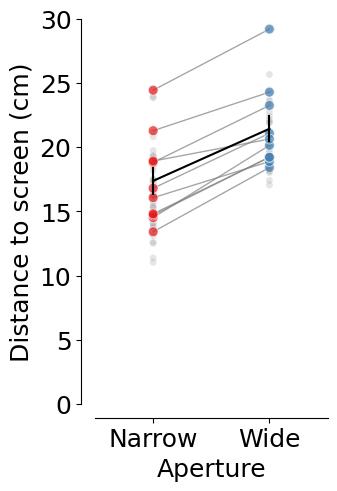

In [124]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))
stats_res = plotting.pairplot_average_decision_point(
    decision_points,
    label_parameter="y",
    ax=ax,
    cmap=plotting.colors_aperture,
    per_mouse=True,
)
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(0, 30)
ax.set_xlabel("Aperture")
ax.set_xticks([0, 1], ["Narrow", "Wide"])
ax.set_ylabel("Distance to screen (cm)")
sns.despine(offset=10)
plt.legend([], [], frameon=False)

plt.savefig(
    save_fig_path + "figure3_dual_occluder_decision_points_distance.svg",
    transparent=True,
)

In [ ]:
decision_points["lab_id"] = 0
for dataset_name in mouse_list:
    # Fetch lab_id for each dataset
    decision_points.loc[decision_points.dataset==dataset_name, "lab_id"] = ((vr4mice.Collab() & f'dataset = "{dataset_name}"') * vr4mice.Labs()).fetch("lab")[0]

2026-02-04 10:21:06,473::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-04 10:21:06,484::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-04 10:21:06,535::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-04 10:21:06,545::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-04 10:21:06,796::INFO::category.py::Using categorical un

mean: 12.04011070556461 +/- 0.4654554795159817
12.0-4.3: TtestResult(statistic=-12.260133388273452, pvalue=1.8309406469185003e-15, df=42)
 mean difference:  3.9081198879131147
mean: 8.131990817651495 +/- 0.388674664871373


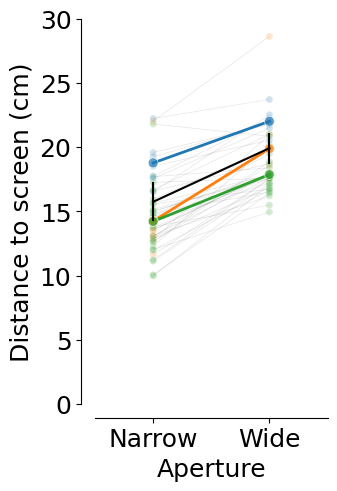

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))
stats_pair = plotting.pairplot_average_decision_point(
    decision_points,
    label_parameter="y",
    ax=ax,
    cmap=plotting.colors_aperture,
    per_lab=True,
)
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(0, 30)
ax.set_xlabel("Aperture")
ax.set_xticks([0, 1], ["Narrow", "Wide"])
ax.set_ylabel("Distance to screen (cm)")
sns.despine(offset=10)
plt.legend([], [], frameon=False)

plt.savefig(
    save_fig_path + "figure3_dual_occluder_decision_points_distance_per_lab.svg",
    transparent=True,
)

In [ ]:
decision_points

,dataset,aperture,trial,trial_length,trial_duration,trial_tortuosity,trial_left_choice,trial_rewarded,x,y,...,heading_dir_cos,velocity_x_fliped,mouse_name,heading_dir_flipped,head_angle_flipped,accuracy,proba_left,trial_length_bin,info_gain,lab_id
0,31726_2025-03-18_1,12.0,2.0,0.11,0.46,1.156218,1.0,0.0,-7.661157,7.156835,...,0.860524,-18.567542,31726,30.624530,-33.350454,1.0,0.703184,"(0.099, 0.119]",0.749676,tolias-lab
1,31726_2025-03-18_1,4.3,3.0,0.82,1.20,1.141038,1.0,0.0,-14.603369,15.294880,...,0.959479,-6.743090,31726,-16.366570,4.839854,1.0,0.777612,"(0.812, 0.832]",0.309597,tolias-lab
2,31726_2025-03-18_1,4.3,4.0,0.33,1.12,1.078895,1.0,1.0,0.958714,-7.319888,...,0.871142,11.773178,31726,-29.408408,3.702867,1.0,0.707094,"(0.317, 0.337]",0.443094,tolias-lab
3,31726_2025-03-18_1,4.3,5.0,0.69,1.38,1.326891,1.0,0.0,-5.255441,12.627049,...,0.996690,-5.821681,31726,4.663168,-16.158682,1.0,0.725060,"(0.673, 0.693]",0.516916,tolias-lab
4,31726_2025-03-18_1,4.3,6.0,0.82,2.38,1.719970,0.0,1.0,7.286824,19.038822,...,-0.853478,12.857246,31726,-148.591945,14.296934,1.0,0.278678,"(0.812, 0.832]",0.557283,tolias-lab
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8949,Pheasant_2024-08-21_1,12.0,245.0,0.42,0.78,1.226944,0.0,1.0,-0.966229,8.551021,...,0.999814,1.741437,Pheasant,1.103730,-18.785892,1.0,0.266832,"(0.416, 0.436]",0.763897,mathis-lab
8950,Pheasant_2024-08-21_1,4.3,247.0,0.45,0.98,1.493241,0.0,1.0,-3.682067,15.887050,...,0.987452,11.699810,Pheasant,-9.086075,-13.314104,1.0,0.228548,"(0.436, 0.455]",0.637013,mathis-lab
8951,Pheasant_2024-08-21_1,4.3,248.0,0.86,3.84,3.841808,1.0,1.0,-5.358221,4.624295,...,0.996593,-0.035295,Pheasant,4.730751,-16.582649,1.0,0.731102,"(0.851, 0.871]",0.470503,mathis-lab
8952,Pheasant_2024-08-21_1,12.0,249.0,0.24,0.46,1.127051,1.0,1.0,-8.917142,4.724449,...,0.999133,5.240578,Pheasant,-2.386581,-1.115902,1.0,0.706857,"(0.238, 0.257]",0.725930,mathis-lab


In [ ]:
decision_points_stats = decision_points.groupby(["dataset", "aperture"], as_index=False)[
    "y"
].mean()
anova_rm = AnovaRM(decision_points_stats, depvar="y", subject="dataset", within=["aperture"])

anova_results = anova_rm.fit()
anova_table = anova_results.summary()
print(anova_table)

                 Anova
         F Value  Num DF  Den DF Pr > F
---------------------------------------
aperture 150.3109 1.0000 42.0000 0.0000



In [ ]:
decision_points_stats.groupby("aperture").y.mean(), decision_points_stats.groupby("aperture").y.sem()

(aperture
 4.3     12.040111
 12.0     8.131991
 Name: y, dtype: float64,
 aperture
 4.3     0.465455
 12.0    0.388675
 Name: y, dtype: float64)

# Relate decision point position to reward rate

In [ ]:
test = decision_points.groupby(["dataset", "aperture"], as_index=False).mean()

In [ ]:
# get first and last quartile of decision points, per dataset
first_quartiles = test[test.aperture==4.3]['y'].quantile(0.2)
last_quartiles = test[test.aperture==4.3]['y'].quantile(0.8)

# get the dfs before q1 and after q3
before_q1 = test[(test.aperture==4.3) & (test['y'] < first_quartiles)] #furthest from screen
after_q3 = test[(test.aperture==4.3) & (test['y'] > last_quartiles)] #closest to screen

# add column for mouse name
before_q1["mouse_name"] = before_q1.dataset.str.split("_").str [0]
after_q3["mouse_name"] = after_q3.dataset.str.split("_").str [0]

/tmp/ipykernel_711291/3073440858.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  before_q1["mouse_name"] = before_q1.dataset.str.split("_").str [0]
/tmp/ipykernel_711291/3073440858.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after_q3["mouse_name"] = after_q3.dataset.str.split("_").str [0]


In [ ]:
before_q1.mouse_name.unique(), after_q3.mouse_name.unique()

(array(['31726', '31728', 'J731', 'Pheasant'], dtype=object),
 array(['J729', 'Jacana', 'Lemming', 'Nightingale', 'Oribi'], dtype=object))

In [ ]:
before_q1.dataset.nunique(), after_q3.dataset.nunique()

(9, 9)

In [ ]:
# get reward rate
trial_df = (TrialMetrics() * vr4mice.Groups() * vr4mice.Labels() * (vr4mice.Dataset() & 'session_label = "ar_discrim_occluders"')).fetch(as_dict=True)
trial_df =  pd.concat([pd.DataFrame(x) for x in trial_df])

# Exclude sessions that were not in the list
trial_df, reward_table = utils.apply_inclusion_criteria(trial_df,
                                                        return_excluded=False)

# Create list of included datasets
mouse_list = trial_df.dataset.unique()
trial_df["mouse_name"] = trial_df.dataset.str.split("_").str [0]

trial_df["lab_id"] = 0
for dataset_name in mouse_list:
    # Fetch lab_id for each dataset
    trial_df.loc[trial_df.dataset==dataset_name, "lab_id"] = ((vr4mice.Collab() & f'dataset = "{dataset_name}"') * vr4mice.Labs()).fetch("lab")[0]

2026-02-04 10:21:11,789::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-04 10:21:11,798::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-04 10:21:11,855::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-04 10:21:11,861::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-04 10:21:11,876::INFO::category.py::Using categorical un

mean: 0.7034696062318463, sem: 0.01661437129648618
12.0-4.3: TtestResult(statistic=6.020836716544765, pvalue=6.021298430409706e-05, df=12)
mean: 0.8670625356096114, sem: 0.015597592114807973
mean: 0.7951417364353957, sem: 0.019065061731189922
12.0-4.3: TtestResult(statistic=3.901005225271365, pvalue=0.0006764185883433609, df=24)
mean: 0.8837975710050653, sem: 0.010775665660272405


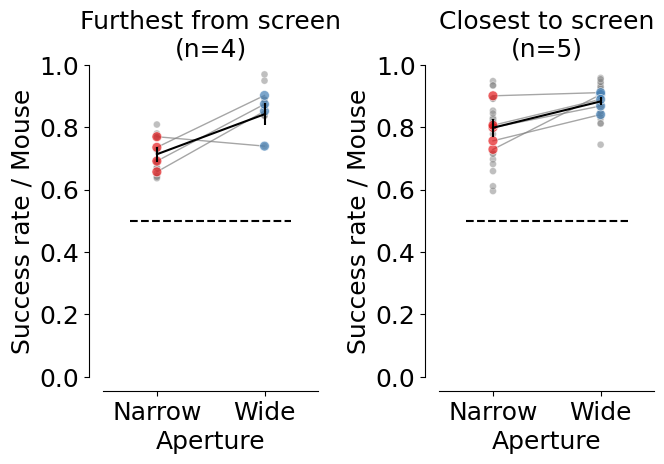

In [ ]:
# plot the lower and upper quartile reward rate for only the sessions in the quartiles
fig, ax = plt.subplots(1, 2, figsize=(7, 5))

counts = plotting.plot_rate(
    df=trial_df[trial_df.mouse_name.isin(before_q1.mouse_name.unique().tolist())],
    label_x="trial_rewarded",
    per_aperture=True,
    ax=ax[0],
    cmap=plotting.colors_aperture[0:2],
    per_mouse=True,
)

ax[0].hlines(
    0.5,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="black",
)
ax[0].set_ylim(0, 1.0)
ax[0].set_xlim(-0.5, 1.5)
ax[0].set_ylabel("Success rate / Mouse")
ax[0].set_xlabel("Aperture")
ax[0].set_xticks([0, 1], ["Narrow", "Wide"])
sns.despine(offset=10, ax=ax[0])
ax[0].legend([], [], frameon=False)
ax[0].set_title(f"Furthest from screen\n(n={counts.mouse_name.nunique()})")

counts2 = plotting.plot_rate(
    df=trial_df[trial_df.mouse_name.isin(after_q3.mouse_name.unique().tolist())],
    label_x="trial_rewarded",
    per_aperture=True,
    ax=ax[1],
    cmap=plotting.colors_aperture[0:2],
    per_mouse=True,
)

ax[1].hlines(
    0.5,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="black",
)
ax[1].set_ylim(0, 1.0)
ax[1].set_xlim(-0.5, 1.5)
ax[1].set_ylabel("Success rate / Mouse")
ax[1].set_xlabel("Aperture")
ax[1].set_xticks([0, 1], ["Narrow", "Wide"])
sns.despine(offset=10, ax=ax[1])
ax[1].legend([], [], frameon=False)
ax[1].set_title(f"Closest to screen\n(n={counts2.mouse_name.nunique()})")
plt.savefig(save_fig_path + "figure3_trial_reward_groups.svg", transparent=True)

plt.tight_layout(pad=2)

In [ ]:
# stats difference between groups
stats_res = ttest_ind(
    counts[counts.aperture=="4.3"]["count"],
    counts2[counts2.aperture=="4.3"]["count"]
)
print("narrow", stats_res)

stats_res = ttest_ind(
    counts[counts.aperture=="12.0"]["count"],
    counts2[counts2.aperture=="12.0"]["count"]
)
print("wide", stats_res)

narrow TtestResult(statistic=-3.1477142046073885, pvalue=0.0032991503807354478, df=36.0)
wide TtestResult(statistic=-0.8951141071836514, pvalue=0.37667219573341515, df=36.0)


### Decision point distance to screen vs. reward rate
Including sessions with the narrow-wide difference in reward rate > 0.25

In [ ]:
trial_df = (TrialMetrics() * vr4mice.Groups() * vr4mice.Labels() * (vr4mice.Dataset() & 'session_label = "ar_discrim_occluders"')).fetch(as_dict=True)
trial_df =  pd.concat([pd.DataFrame(x) for x in trial_df])
# Exclude sessions that were not in the list
trial_df, reward_table = utils.apply_inclusion_criteria(trial_df,
                                                        return_excluded=False,
                                                        consider_reward_drop=False)
# Create list of included datasets
mouse_list = trial_df.dataset.unique()
trial_df["mouse_name"] = trial_df.dataset.str.split("_").str [0]

In [ ]:
# This takes a while to fetch because we need to fetch data for all trials (4 min 20 secs) 
dataset_list = []
for d in mouse_list:
    print(d)
    try:
        if len(InterpolatedTrials() & f'dataset = "{d}"') > 0:
            dataset_list.append(pd.DataFrame((InterpolatedTrials() & f'dataset = "{d}"').fetch(as_dict=True)[0]))
        else:
            print("dataset missing")
    except Exception as err:
        print(err, " dataset missing")
interpolated_df = pd.concat(dataset_list)
interpolated_df["mouse_name"] = interpolated_df.dataset.str.split("_").str [0]

31726_2025-03-18_1
31726_2025-03-19_1
31726_2025-03-20_1
31726_2025-03-21_1
31728_2025-03-05_1
31728_2025-03-06_1
31728_2025-03-07_1
31728_2025-03-20_1
31728_2025-03-21_1
J729_2024-11-30_1
J729_2024-12-01_1
J729_2024-12-02_1
J729_2024-12-03_1
J729_2024-12-04_1
J729_2024-12-10_1
J731_2024-12-05_1
J731_2024-12-09_1
Jacana_2024-08-13_1
Jacana_2024-08-14_1
Jacana_2024-08-15_1
Jacana_2024-08-16_1
Jacana_2024-08-19_1
Kiwi_2024-08-10_2
Kiwi_2024-08-11_4
Kiwi_2024-08-12_2
Kiwi_2024-08-13_1
Kiwi_2024-08-14_1
Lemming_2024-08-10_1
Lemming_2024-08-11_1
Lemming_2024-08-12_1
Lemming_2024-08-13_1
Nightingale_2024-08-10_1
Nightingale_2024-08-11_1
Nightingale_2024-08-12_1
Nightingale_2024-08-13_1
Nightingale_2024-08-14_1
Oribi_2024-08-16_1
Oribi_2024-08-19_1
Oribi_2024-08-20_1
Oribi_2024-08-21_1
Oribi_2024-08-22_1
Pheasant_2024-08-15_2
Pheasant_2024-08-16_1
Pheasant_2024-08-19_1
Pheasant_2024-08-20_1
Pheasant_2024-08-21_1


In [ ]:
interpolated_df.dataset.nunique(), interpolated_df.mouse_name.nunique()

(46, 10)

In [ ]:
model_labels = regression.model_labels 

In [ ]:
interpolated_df["aperture"] = interpolated_df["aperture"].astype(float)

df_model, coef = regression.predict_decision(
    df=interpolated_df, label=model_labels, per_mouse=True
)

In [ ]:
decision_points = regression.find_decision_point(df_model, 
                                                 threshold_uncertainty=0.3)

In [ ]:
decision_points

,dataset,aperture,trial,trial_length,trial_duration,trial_tortuosity,trial_left_choice,trial_rewarded,x,y,...,optimal_p,local_tortuosity,head_angle_sin,head_angle_cos,heading_dir_sin,heading_dir_cos,velocity_x_fliped,mouse_name,accuracy,proba_left
0,31726_2025-03-18_1,12.0,2.0,0.11,0.46,1.156218,1.0,0.0,-7.661157,7.156835,...,25.000000,0.988944,0.549759,0.835324,-0.509410,0.860524,-18.567542,31726,1.0,0.705451
1,31726_2025-03-18_1,4.3,3.0,0.82,1.20,1.141038,1.0,0.0,-14.603369,15.294880,...,1.000000,1.000450,-0.084371,0.996434,0.281782,0.959479,-6.743090,31726,1.0,0.777194
2,31726_2025-03-18_1,4.3,4.0,0.34,1.12,1.078895,1.0,1.0,0.808289,-6.787732,...,1.000000,1.006974,-0.090622,0.995885,0.490744,0.871304,17.225556,31726,1.0,0.729419
3,31726_2025-03-18_1,4.3,5.0,0.69,1.38,1.326891,1.0,0.0,-5.255441,12.627049,...,1.000000,1.002200,0.278299,0.960495,-0.081298,0.996690,-5.821681,31726,1.0,0.725908
4,31726_2025-03-18_1,4.3,6.0,0.82,2.38,1.719970,0.0,1.0,7.286824,19.038822,...,15.817019,1.003194,0.246947,0.969029,-0.521130,-0.853478,12.857246,31726,1.0,0.260547
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9406,Pheasant_2024-08-21_1,12.0,245.0,0.42,0.78,1.226944,0.0,1.0,-0.966229,8.551021,...,1.000000,1.008666,-0.322033,0.946729,0.019263,0.999814,1.741437,Pheasant,1.0,0.267380
9407,Pheasant_2024-08-21_1,4.3,247.0,0.45,0.98,1.493241,0.0,1.0,-3.682067,15.887050,...,25.000000,1.007231,-0.230289,0.973122,-0.157918,0.987452,11.699810,Pheasant,1.0,0.234738
9408,Pheasant_2024-08-21_1,4.3,248.0,0.86,3.84,3.841808,1.0,1.0,-5.358221,4.624295,...,1.000000,1.000084,0.285398,0.958409,-0.082473,0.996593,-0.035295,Pheasant,1.0,0.762540
9409,Pheasant_2024-08-21_1,12.0,249.0,0.24,0.46,1.127051,1.0,1.0,-8.917142,4.724449,...,1.000000,1.000317,0.019475,0.999810,0.041642,0.999133,5.240578,Pheasant,1.0,0.709554


Aperture 4.3: r=-0.6724282092120393, p=0.03314866973896918
Aperture 12.0: r=-0.1873663005432035, p=0.6042244027382984


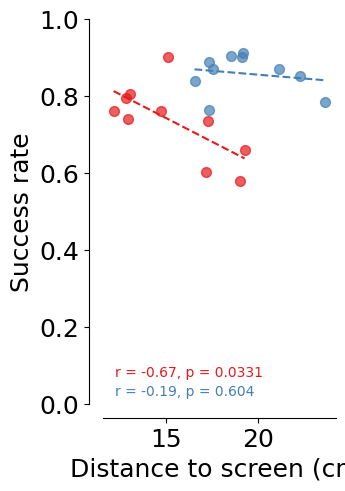

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))

for aperture, color, ypos in zip(decision_points.sort_values("aperture").aperture.unique(), 
                                     plotting.colors_aperture,
                                     [0.10, 0.05]):
    x = abs(decision_points[decision_points.aperture==aperture].groupby(
        "mouse_name")["y"].mean().values - 27)
    y = trial_df[(trial_df.aperture==aperture)].groupby(
        "mouse_name")["trial_rewarded"].mean().values


    # scatter
    ax.scatter(
        x, y,
        color=color,
        alpha=0.7,
        s=50
    )

    # regression line
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = slope * x_fit + intercept
    ax.plot(x_fit, y_fit, color=color, linestyle="--")
    
    print(f"Aperture {aperture}: r={r_value}, p={p_value}")

    # annotate correlation
    ax.text(
        0.05, ypos,
        f"r = {r_value:.2f}, p = {p_value:.3g}",
        transform=ax.transAxes,
        va="top", ha="left",
        color=color
    )

    ax.set_xlabel("Distance to screen (cm)")
    ax.set_ylabel("Success rate")
    ax.set_ylim(0, 1.0)
    sns.despine(offset=10, ax=ax)

plt.savefig(save_fig_path + "figure3_dual_occluder_decision_point_vs_performance.svg", transparent=True)